## Step 1 - Init python stuff

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import TensorBoard

import sys
sys.path.append("/home/onyxia/gen-ai-fwi")
from models.DCGAN    import DCGAN
from callbacks.ImagesCallback import ImagesCallback

import fidle

I0000 00:00:1777112016.108829    7180 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13366 MB memory:  -> device: 0, name: NVIDIA A2, pci bus id: 0000:17:00.0, compute capability: 8.6


## Step 2 - Parameters

In [38]:
latent_dim    = 128

scale         = .01
epochs        = 5
batch_size    = 32
num_img       = 12
fit_verbosity = 1

## Step 3 - Load data

In [39]:


# =========================================================
# 1. RECHARGEMENT DU PARQUET DEPUIS MINIO
# =========================================================
MY_BUCKET = "matheo"
CHEMIN_FICHIER_OUT = "diffusion/data/fwi_se_spain_28x28.parquet"
VALUE_COL = "fwi-daily-proj"
GRID_SIZE = 28

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER_OUT}", "rb") as f:
    df_loaded = pd.read_parquet(f)

print(f"DataFrame rechargé : {df_loaded.shape}")
print(df_loaded.head())

# =========================================================
# 2. RECONSTRUCTION DU TENSEUR (N, 28, 28)
# =========================================================
# On trie par (time, lat, lon) pour retrouver exactement l'ordre du ravel
# utilisé lors de la sauvegarde. `meshgrid(se_lon_centers, se_lat_centers)`
# produit LAT variant par ligne, LON variant par colonne ; le ravel parcourt
# donc les lignes (lat fixe, lon croissante) puis les latitudes dans l'ordre
# où elles apparaissent dans se_lat_centers (croissante).
df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

# Vérification : chaque date doit avoir exactement 784 pixels
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all(), \
    f"Certaines dates n'ont pas {GRID_SIZE*GRID_SIZE} pixels"

# Conversion en tenseur (N, 28, 28)
n_dates = df_sorted["time"].nunique()
X = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE,1)
dates = np.sort(df_sorted["time"].unique())

print(f"Tenseur X : {X.shape}")   # (N, 28, 28)
print(f"min = {X.min():.3f}, max = {X.max():.3f}, mean = {X.mean():.3f}")


DataFrame rechargé : (10308816, 4)
        time        lat       lon  fwi-daily-proj
0 1970-01-01  37.267857 -8.548214             1.0
1 1970-01-01  37.267857 -8.244643             1.0
2 1970-01-01  37.267857 -7.941071             1.0
3 1970-01-01  37.267857 -7.637500             1.0
4 1970-01-01  37.267857 -7.333929             1.0
Tenseur X : (13149, 28, 28, 1)
min = 0.000, max = 211.122, mean = 15.011


## Step 4 - Visualize data

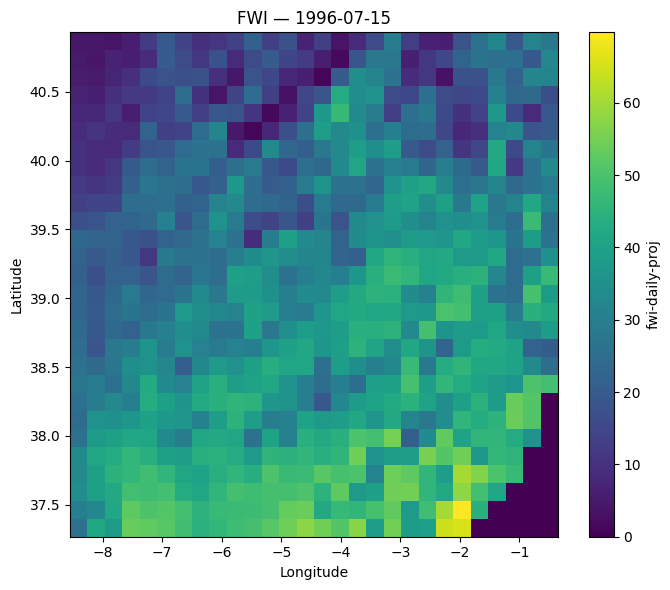

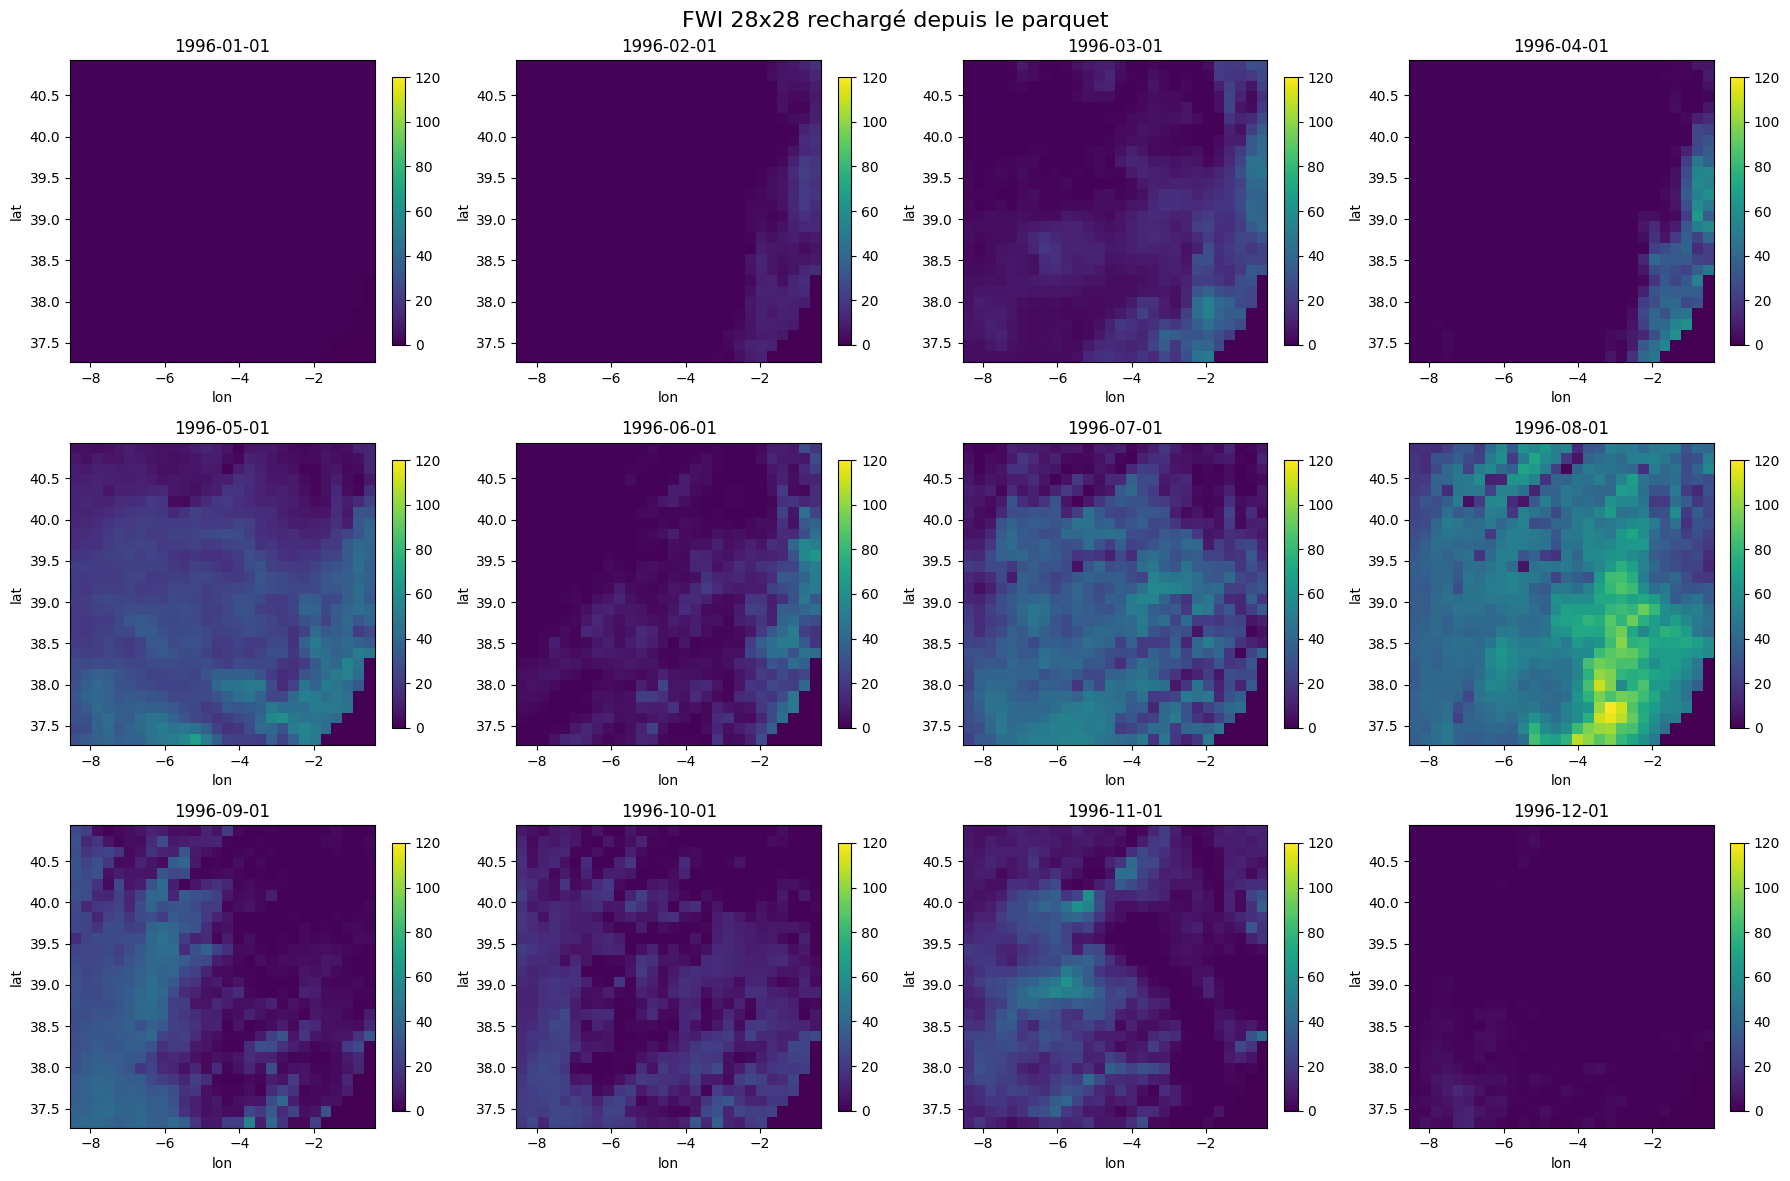

In [40]:
import matplotlib.pyplot as plt

# =========================================================
# 3. RÉAFFICHAGE D'UNE CARTE AVEC COORDONNÉES LON/LAT
# =========================================================
# On récupère les centres de pixels depuis le dataframe rechargé
lon_centers = np.sort(df_loaded["lon"].unique())   # 28 valeurs
lat_centers = np.sort(df_loaded["lat"].unique())   # 28 valeurs
assert len(lon_centers) == GRID_SIZE and len(lat_centers) == GRID_SIZE

# Emprise géographique (pour axer le plot)
extent = [lon_centers.min(), lon_centers.max(),
          lat_centers.min(), lat_centers.max()]

# ---------- Option 1 : une seule date ----------
def plot_one_date(date, X, dates, extent, title_prefix="FWI"):
    i = np.where(dates == np.datetime64(date))[0]
    if len(i) == 0:
        print(f"Date {date} non trouvée dans le dataset.")
        return
    i = i[0]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(X[i], origin="lower", extent=extent,
                   cmap="viridis", aspect="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title_prefix} — {str(dates[i])[:10]}")
    plt.colorbar(im, ax=ax, label=VALUE_COL)
    plt.tight_layout()
    plt.show()

plot_one_date("1996-07-15", X, dates, extent)


# ---------- Option 2 : grille 3x4 pour les 12 mois de 1996 ----------
dates_plot = ['1996-01-01','1996-02-01','1996-03-01',
              '1996-04-01','1996-05-01','1996-06-01',
              '1996-07-01','1996-08-01','1996-09-01',
              '1996-10-01','1996-11-01','1996-12-01']
dates_plot = [np.datetime64(d) for d in dates_plot]

# Échelle de couleur commune sur les 12 mois
indices = [np.where(dates == d)[0][0] for d in dates_plot if d in dates]
stack = X[indices]
vmin, vmax = stack.min(), stack.max()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    im = ax.imshow(X[idx], origin="lower", extent=extent,
                   cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(str(dates[idx])[:10])
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    plt.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle("FWI 28x28 rechargé depuis le parquet", fontsize=16)
plt.tight_layout()
plt.show()

## Step 5 - Create a discriminator

In [41]:
inputs  = keras.Input(shape=(28, 28, 1))
x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x)
z       = layers.Dense(1, activation="sigmoid")(x)
# Stride = 2 to downsample
# padding = "same" to keep the output size the same as input size
# (except for the last layer)

discriminator = keras.Model(inputs, z, name="discriminator")
discriminator.summary()

/opt/python/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,609 (1.51 MB)

 Trainable params: 396,609 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64)(inputs)
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(128,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(256,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)
#  sigmoid to get output in [0,1] range (because of the normalization of the input images)

# here we use UpSampling2D + Conv2D (to mix the features) instead of Conv2DTranspose
# to avoid checkerboard artifacts

generator = keras.Model(inputs, outputs, name="generator")
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 1)      │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 779,969 (2.98 MB)

 Trainable params: 779,969 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Build, compile and train our DCGAN 

In [43]:
gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

Fidle DCGAN is ready :-)  latent dim = 128
